<font color="#CA0032"><h1 align="left"><b>Exploración del dataset (EDA)</b></h1></font>
<font color="#6E6E6E"><h2 align="left"><b>Predicción de ventas Rossmann · Práctica B3—T5</b></h2></font>

Análisis exploratorio **completo** de los datos disponibles para la práctica de *entradas heterogéneas*.
El objetivo de este cuaderno es **entender los datos antes de modelar**: estructura, calidad, la
variable objetivo, los patrones temporales, el efecto de las variables exógenas y los atributos
estáticos de cada tienda. Todas las conclusiones se recogen en la sección final, orientadas a las
decisiones de preprocesado y arquitectura del modelo.

### Contenido
1. Librerías y configuración
2. Carga de datos
3. Estructura y tipos
4. Calidad de los datos (nulos, duplicados, coherencia)
5. Variable objetivo: `Sales`
6. `Customers` y su relación con las ventas
7. Análisis temporal (tendencia y estacionalidad)
8. Variables exógenas / eventos (`Promo`, `StateHoliday`, `SchoolHoliday`, aperturas)
9. Atributos de tienda (`store.csv`)
10. Correlaciones entre variables numéricas
11. Comparación `train` vs `test`
12. `submission` y "las 10 tiendas"
13. **Conclusiones orientadas al modelado**

## <font color='#CA3532'>**1. Librerías y configuración**</font>

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from IPython.display import display

%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

np.random.seed(7)
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", "{:.3f}".format)

# Estilo de las gráficas
plt.rcParams["figure.figsize"]   = (11, 4)
plt.rcParams["axes.grid"]        = True
plt.rcParams["grid.alpha"]       = 0.3
plt.rcParams["axes.spines.top"]  = False
plt.rcParams["axes.spines.right"]= False
ROJO  = "#CA0032"
GRIS  = "#6E6E6E"
AZUL  = "#2E5A87"

## <font color='#CA3532'>**2. Carga de datos**</font>

Los datos de Rossmann se distribuyen en cuatro ficheros:

| Fichero | Contenido | Granularidad |
|---|---|---|
| `train.csv` | Histórico **diario** de ventas por tienda | (tienda, día) |
| `test.csv` | Registros a predecir | (tienda, día) |
| `store.csv` | Información **estática** de cada tienda | (tienda) |
| `submission.csv` | Plantilla / ejemplo del formato de entrega | (tienda, día) |

In [2]:
DATASET_DIR = Path("dataset_completo_Rossmann-20260604T174330Z-3-001") / "dataset_completo_Rossmann"
if not DATASET_DIR.exists():
    candidates = sorted(Path(".").glob("**/dataset_completo_Rossmann"))
    if not candidates:
        raise FileNotFoundError("No se ha encontrado la carpeta dataset_completo_Rossmann")
    DATASET_DIR = candidates[0]

train      = pd.read_csv(DATASET_DIR / "train.csv",      parse_dates=["Date"], low_memory=False)
test       = pd.read_csv(DATASET_DIR / "test.csv",       parse_dates=["Date"], low_memory=False)
store      = pd.read_csv(DATASET_DIR / "store.csv",      low_memory=False)
submission = pd.read_csv(DATASET_DIR / "submission.csv")

print("train     :", train.shape)
print("test      :", test.shape)
print("store     :", store.shape)
print("submission:", submission.shape)

train     : (1001599, 10)
test      : (1115, 9)
store     : (1115, 10)
submission: (1115, 2)


In [3]:
print("Primeras filas de train:");      display(train.head())
print("Primeras filas de test:");       display(test.head())
print("Primeras filas de store:");      display(store.head())
print("Primeras filas de submission:"); display(submission.head())

Primeras filas de train:


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,Id
0,1,5,2015-07-17,4852,519,1,1,0,0,303445
1,2,5,2015-07-17,4518,495,1,1,0,1,959585
2,3,5,2015-07-17,6679,673,1,1,0,1,739744
3,4,5,2015-07-17,10514,1343,1,1,0,1,864001
4,5,5,2015-07-17,4355,513,1,1,0,1,981931


Primeras filas de test:


,Id,Store,DayOfWeek,Date,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,879066,1,5,2015-07-31,555,1,1,0,1
1,37135,2,5,2015-07-31,625,1,1,0,1
2,285919,3,5,2015-07-31,821,1,1,0,1
3,744348,4,5,2015-07-31,1498,1,1,0,1
4,556250,5,5,2015-07-31,559,1,1,0,1


Primeras filas de store:


,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.000,9.000,2008.000,0,NaN,NaN,NaN
1,2,a,a,570.000,11.000,2007.000,1,13.000,2010.000,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.000,12.000,2006.000,1,14.000,2011.000,"Jan,Apr,Jul,Oct"
3,4,c,c,620.000,9.000,2009.000,0,NaN,NaN,NaN
4,5,a,a,29910.000,4.000,2015.000,0,NaN,NaN,NaN


Primeras filas de submission:


,Id,Sales
0,879066,5250.649
1,37135,5997.647
2,285919,9207.910
3,744348,12377.561
4,556250,5296.303


## <font color='#CA3532'>**3. Estructura y tipos**</font>

In [4]:
def resumen_dataframe(df, nombre):
    return pd.Series({
        "filas":      len(df),
        "columnas":   df.shape[1],
        "tiendas":    df["Store"].nunique() if "Store" in df else np.nan,
        "fecha_min":  df["Date"].min() if "Date" in df else pd.NaT,
        "fecha_max":  df["Date"].max() if "Date" in df else pd.NaT,
        "dias_dist.": df["Date"].nunique() if "Date" in df else np.nan,
        "duplicados": df.duplicated().sum(),
    }, name=nombre)

resumen = pd.concat([
    resumen_dataframe(train, "train"),
    resumen_dataframe(test,  "test"),
    resumen_dataframe(store, "store"),
], axis=1).T
display(resumen)

,filas,columnas,tiendas,fecha_min,fecha_max,dias_dist.,duplicados
train,1001599,10,1115,2013-01-01 00:00:00,2015-07-17 00:00:00,928,0
test,1115,9,1115,2015-07-31 00:00:00,2015-07-31 00:00:00,1,0
store,1115,10,1115,NaT,NaT,NaN,0


In [5]:
# Tipos de dato de cada tabla
print("dtypes train:\n", train.dtypes, "\n")
print("dtypes test :\n", test.dtypes,  "\n")
print("dtypes store:\n", store.dtypes)

dtypes train:
 Store                     int64
DayOfWeek                 int64
Date             datetime64[us]
Sales                     int64
Customers                 int64
Open                      int64
Promo                     int64
StateHoliday                str
SchoolHoliday             int64
Id                        int64
dtype: object 

dtypes test :
 Id                        int64
Store                     int64
DayOfWeek                 int64
Date             datetime64[us]
Customers                 int64
Open                      int64
Promo                     int64
StateHoliday              int64
SchoolHoliday             int64
dtype: object 

dtypes store:
 Store                          int64
StoreType                        str
Assortment                       str
CompetitionDistance          float64
CompetitionOpenSinceMonth    float64
CompetitionOpenSinceYear     float64
Promo2                         int64
Promo2SinceWeek              float64
Promo2SinceYear    

**Observaciones de estructura**

- `train`: ~**1,0 M de filas** (1115 tiendas × 928 días, 2013-01-01 → 2015-07-17).
- `test`: **1115 filas**, un único día (**2015-07-31**), una fila por tienda. No incluye `Sales`.
- `store`: **1115 filas**, una por tienda, con sus atributos estáticos.
- Cuidado: `StateHoliday` llega como **texto** en `train` (`'0','a','b','c'`) pero como **entero** en `test`;
  habrá que homogeneizarlo antes de modelar.

## <font color='#CA3532'>**4. Calidad de los datos**</font>

### Valores nulos

In [6]:
nulos = pd.concat({
    "train": train.isna().sum(),
    "test":  test.isna().sum(),
    "store": store.isna().sum(),
}, axis=1).fillna(0).astype(int)
nulos["%_store"] = (nulos["store"] / len(store) * 100).round(1)
display(nulos[nulos[["train", "test", "store"]].sum(axis=1) > 0])

,train,test,store,%_store
CompetitionDistance,0,0,3,0.300
CompetitionOpenSinceMonth,0,0,354,31.700
CompetitionOpenSinceYear,0,0,354,31.700
Promo2SinceWeek,0,0,544,48.800
Promo2SinceYear,0,0,544,48.800
PromoInterval,0,0,544,48.800


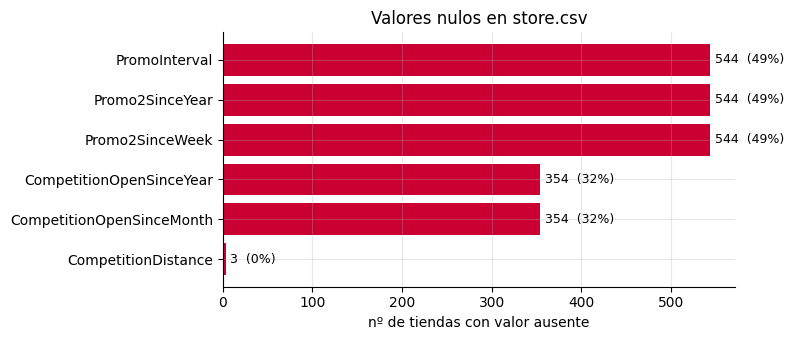

In [7]:
# Visualización de los nulos de store.csv
nul_store = store.isna().sum()
nul_store = nul_store[nul_store > 0].sort_values()
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.barh(nul_store.index, nul_store.values, color=ROJO)
for i, v in enumerate(nul_store.values):
    ax.text(v + 5, i, f"{v}  ({v/len(store)*100:.0f}%)", va="center", fontsize=9)
ax.set_title("Valores nulos en store.csv")
ax.set_xlabel("nº de tiendas con valor ausente")
plt.tight_layout(); plt.show()

**Lectura de los nulos** — no son errores, tienen un significado:

- `CompetitionDistance` (3 nulos): no consta competencia cercana → se imputará con la mediana.
- `CompetitionOpenSinceMonth/Year` (354): se desconoce **cuándo** abrió la competencia.
- `Promo2SinceWeek/Year` y `PromoInterval` (**544**): coinciden exactamente con las tiendas que **no
  participan** en `Promo2` (`Promo2 == 0`). El nulo significa "no aplica" → se imputará con `0` / `"None"`.
- `train` y `test` **no tienen nulos**.

### Duplicados y coherencia `Open` ↔ `Sales`

In [8]:
print("Duplicados  -> train:", train.duplicated().sum(),
      "| test:", test.duplicated().sum(),
      "| store:", store.duplicated().sum())

# ¿Las ventas a 0 coinciden con tienda cerrada?
ct = pd.crosstab(train["Open"], train["Sales"].eq(0),
                 rownames=["Open"], colnames=["Sales == 0"])
print("\nTabla de contingencia Open vs Sales==0:")
display(ct)

print("Filas con Sales == 0 :", int((train.Sales == 0).sum()),
      f"({(train.Sales == 0).mean()*100:.1f}%)")
print("Filas con Open  == 0 :", int((train.Open  == 0).sum()),
      f"({(train.Open  == 0).mean()*100:.1f}%)")
print("Open==1 pero Sales==0:", int(((train.Open == 1) & (train.Sales == 0)).sum()))
print("Open==0 pero Sales>0 :", int(((train.Open == 0) & (train.Sales >  0)).sum()))

Duplicados  -> train: 0 | test: 0 | store: 0

Tabla de contingencia Open vs Sales==0:


Sales == 0,False,True
Open,,
0,0,170627
1,830918,54


Filas con Sales == 0 : 170681 (17.0%)
Filas con Open  == 0 : 170627 (17.0%)
Open==1 pero Sales==0: 54
Open==0 pero Sales>0 : 0


**Coherencia perfecta:** una tienda cerrada (`Open==0`) vende **siempre** 0, y prácticamente todas las
ventas nulas corresponden a cierres (solo **54** casos abiertos con venta 0). Es decir, `Open` actúa como
un *interruptor* casi determinista sobre `Sales`. Esto sugiere modelar **solo los días abiertos** y forzar
`Sales = 0` cuando `Open == 0`.

## <font color='#CA3532'>**5. Variable objetivo: `Sales`**</font>

In [9]:
# Copias de trabajo (no tocamos los ficheros originales) + variables de calendario
train_eda = train.copy()
train_eda["StateHoliday"] = train_eda["StateHoliday"].astype(str).replace({"0.0": "0"})
train_eda["Year"]       = train_eda["Date"].dt.year
train_eda["Month"]      = train_eda["Date"].dt.month
train_eda["Day"]        = train_eda["Date"].dt.day
train_eda["WeekOfYear"] = train_eda["Date"].dt.isocalendar().week.astype(int)

# La mayoría de los análisis de venta se hacen sobre tiendas ABIERTAS
abiertas = train_eda[train_eda["Open"] == 1].copy()
abiertas_store = abiertas.merge(store, on="Store", how="left")

print("Estadísticos de Sales (TODOS los registros):")
display(train_eda["Sales"].describe())
print("Estadísticos de Sales (solo tiendas ABIERTAS):")
display(abiertas["Sales"].describe())
print("Asimetría (skew) de Sales en abiertas:", round(abiertas["Sales"].skew(), 3))

Estadísticos de Sales (TODOS los registros):


count   1001599.000
mean       5770.573
std        3852.568
min           0.000
25%        3722.000
50%        5741.000
75%        7854.000
max       41551.000
Name: Sales, dtype: float64

Estadísticos de Sales (solo tiendas ABIERTAS):


count   830972.000
mean      6955.469
std       3106.186
min          0.000
25%       4858.000
50%       6368.000
75%       8360.000
max      41551.000
Name: Sales, dtype: float64

Asimetría (skew) de Sales en abiertas: 1.596


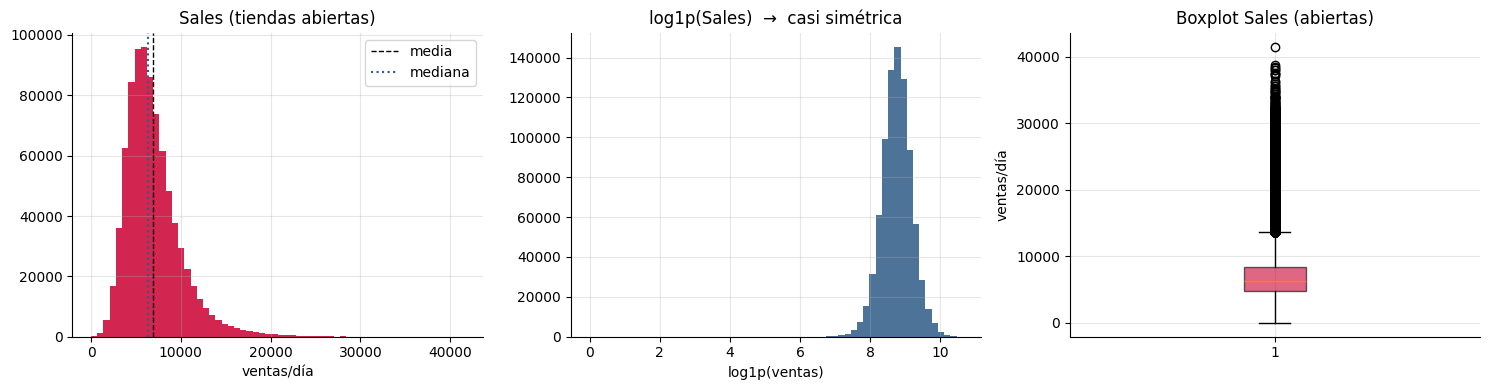

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(abiertas["Sales"], bins=60, color=ROJO, alpha=0.85)
axes[0].axvline(abiertas["Sales"].mean(),   color="black", ls="--", lw=1, label="media")
axes[0].axvline(abiertas["Sales"].median(), color=AZUL,    ls=":",  lw=1.5, label="mediana")
axes[0].set_title("Sales (tiendas abiertas)"); axes[0].set_xlabel("ventas/día"); axes[0].legend()

axes[1].hist(np.log1p(abiertas["Sales"]), bins=60, color=AZUL, alpha=0.85)
axes[1].set_title("log1p(Sales)  →  casi simétrica"); axes[1].set_xlabel("log1p(ventas)")

axes[2].boxplot(abiertas["Sales"], vert=True, showfliers=True,
                patch_artist=True, boxprops=dict(facecolor=ROJO, alpha=0.6))
axes[2].set_title("Boxplot Sales (abiertas)"); axes[2].set_ylabel("ventas/día")

plt.tight_layout(); plt.show()

**Sobre la variable objetivo**

- `Sales` está **muy sesgada a la derecha** (asimetría positiva, cola larga de tiendas con mucha venta).
- La transformación **`log1p(Sales)`** la vuelve casi simétrica → suele ayudar a entrenar redes neuronales
  y a estabilizar el error relativo. Buena candidata como objetivo del modelo.
- En tiendas abiertas, la mediana ronda ~6 400 €/día y hay valores extremos por encima de 40 000.

## <font color='#CA3532'>**6. `Customers` y su relación con las ventas**</font>

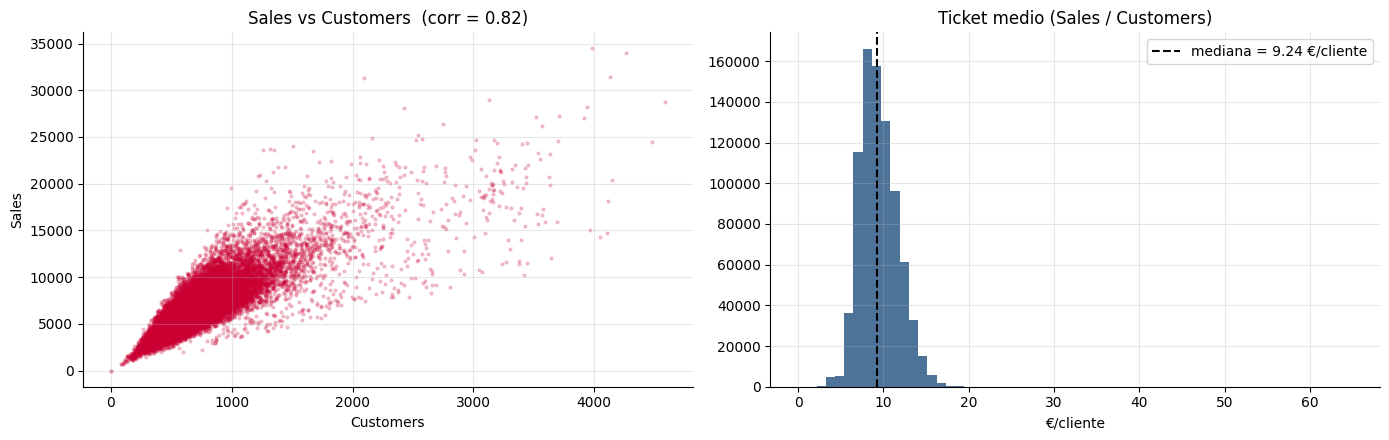

Correlación Sales–Customers (abiertas): 0.824
Ticket medio (€/cliente): media=9.49, mediana=9.24


In [11]:
abiertas_pos = abiertas[abiertas["Customers"] > 0].copy()
abiertas_pos["SalesPerCustomer"] = abiertas_pos["Sales"] / abiertas_pos["Customers"]
corr_sc = abiertas[["Sales", "Customers"]].corr().iloc[0, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
muestra = abiertas.sample(20000, random_state=7)
axes[0].scatter(muestra["Customers"], muestra["Sales"], s=4, alpha=0.2, color=ROJO)
axes[0].set_title(f"Sales vs Customers  (corr = {corr_sc:.2f})")
axes[0].set_xlabel("Customers"); axes[0].set_ylabel("Sales")

axes[1].hist(abiertas_pos["SalesPerCustomer"], bins=60, color=AZUL, alpha=0.85)
axes[1].axvline(abiertas_pos["SalesPerCustomer"].median(), color="black", ls="--",
                label=f"mediana = {abiertas_pos['SalesPerCustomer'].median():.2f} €/cliente")
axes[1].set_title("Ticket medio (Sales / Customers)"); axes[1].set_xlabel("€/cliente"); axes[1].legend()
plt.tight_layout(); plt.show()

print(f"Correlación Sales–Customers (abiertas): {corr_sc:.3f}")
print(f"Ticket medio (€/cliente): media={abiertas_pos['SalesPerCustomer'].mean():.2f}, "
      f"mediana={abiertas_pos['SalesPerCustomer'].median():.2f}")

**`Customers` es el predictor más fuerte... pero es delicado**

- Correlación **0,82** con `Sales`: el número de clientes explica gran parte de la venta y el ticket medio
  es muy estable (~9,5 €/cliente).
- ⚠️ **Riesgo de fuga de información (*leakage*)**: en un escenario real **no se conoce el número de clientes
  *antes* de que ocurra el día**. En este dataset el `test.csv` *sí* incluye `Customers`, lo que facilita la
  predicción, pero conviene: (a) dejarlo claro en la reflexión y (b) valorar un modelo **sin** `Customers`
  (o que prediga primero los clientes) para que la solución sea realista.

## <font color='#CA3532'>**7. Análisis temporal**</font>

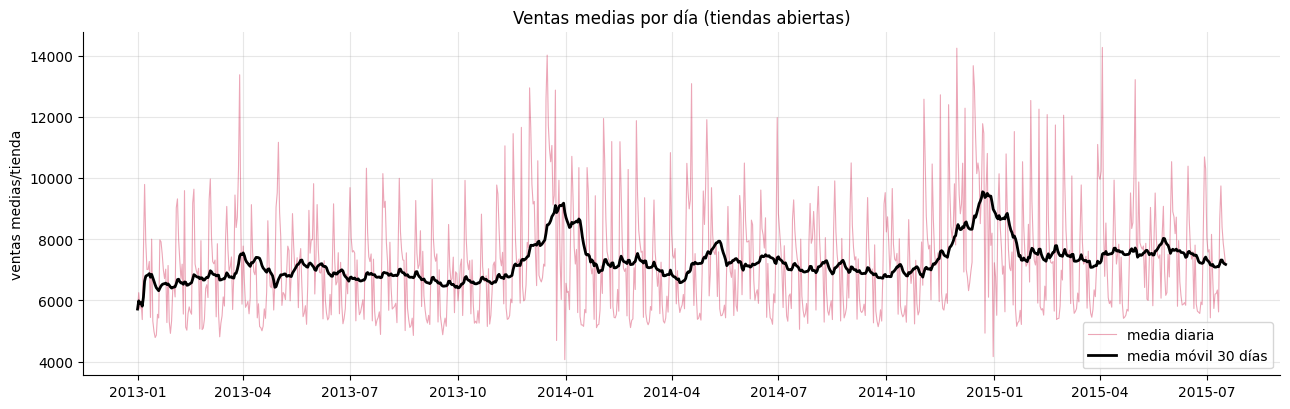

In [12]:
# Serie diaria agregada sobre tiendas abiertas
diario = abiertas.groupby("Date").agg(
    sales_mean=("Sales", "mean"),
    sales_sum=("Sales", "sum"),
    n_tiendas=("Store", "nunique"),
).reset_index()
diario["mm30"] = diario["sales_mean"].rolling(30, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(13, 4.2))
ax.plot(diario["Date"], diario["sales_mean"], color=ROJO, alpha=0.35, lw=0.8, label="media diaria")
ax.plot(diario["Date"], diario["mm30"], color="black", lw=2, label="media móvil 30 días")
ax.set_title("Ventas medias por día (tiendas abiertas)")
ax.set_ylabel("ventas medias/tienda"); ax.legend()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.tight_layout(); plt.show()

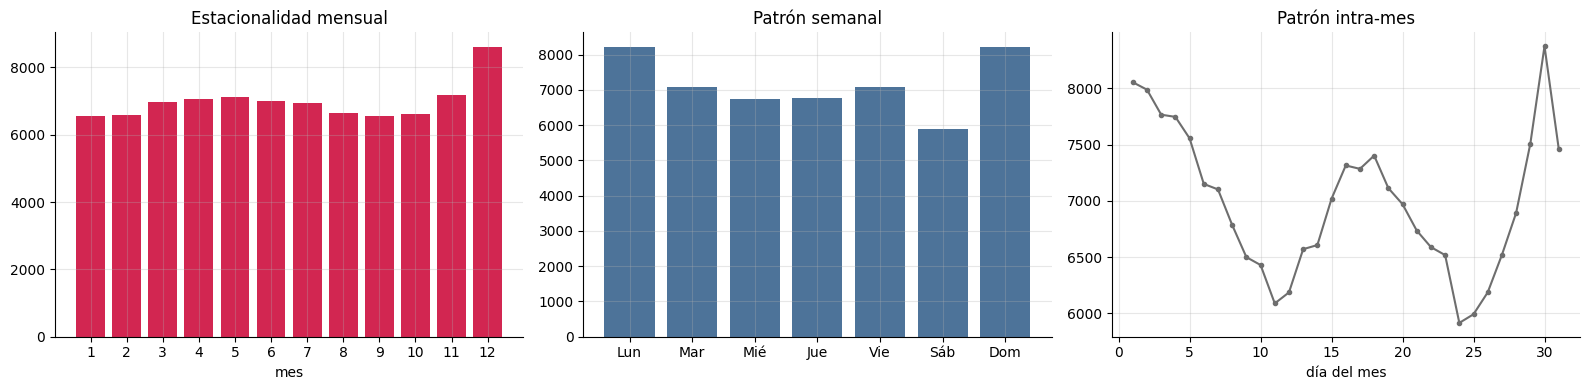

Ventas medias por año (abiertas):


Year
2013   6814.000
2014   7025.000
2015   7098.000
Name: Sales, dtype: float64

Nº de tiendas abiertas en domingo (DayOfWeek=7): 33 de 1115


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# (a) Estacionalidad anual: ventas medias por mes
por_mes = abiertas.groupby("Month")["Sales"].mean()
axes[0].bar(por_mes.index, por_mes.values, color=ROJO, alpha=0.85)
axes[0].set_title("Estacionalidad mensual"); axes[0].set_xlabel("mes")
axes[0].set_xticks(range(1, 13))

# (b) Patrón semanal: ventas medias por día de la semana
dias = ["Lun", "Mar", "Mié", "Jue", "Vie", "Sáb", "Dom"]
por_dow = abiertas.groupby("DayOfWeek")["Sales"].mean()
axes[1].bar(range(1, 8), por_dow.reindex(range(1, 8)).values, color=AZUL, alpha=0.85)
axes[1].set_title("Patrón semanal"); axes[1].set_xticks(range(1, 8)); axes[1].set_xticklabels(dias)

# (c) Patrón intra-mes: ventas medias por día del mes
por_dia = abiertas.groupby("Day")["Sales"].mean()
axes[2].plot(por_dia.index, por_dia.values, color=GRIS, marker="o", ms=3)
axes[2].set_title("Patrón intra-mes"); axes[2].set_xlabel("día del mes")

plt.tight_layout(); plt.show()

# Comparativa por año (ventas medias)
print("Ventas medias por año (abiertas):")
display(abiertas.groupby("Year")["Sales"].mean().round(0))
print("Nº de tiendas abiertas en domingo (DayOfWeek=7):",
      abiertas[abiertas.DayOfWeek == 7]["Store"].nunique(), "de 1115")

**Patrones temporales detectados**

- **Estacionalidad anual** marcada: gran **pico en diciembre** (campaña de Navidad) y meses de verano más flojos.
- **Estacionalidad semanal**: **lunes** es el día más fuerte; las ventas decaen hacia el **sábado** (el más bajo);
  el **domingo** es alto *en promedio* pero **engañoso**: solo abren ~33 tiendas (las que abren venden mucho).
- **Patrón intra-mes**: repunte a **principio y fin de mes** (pagos de nóminas).
- Estas tres periodicidades justifican incluir `DayOfWeek`, `Month`/`WeekOfYear` y `Day` como entradas exógenas.

## <font color='#CA3532'>**8. Variables exógenas / eventos**</font>

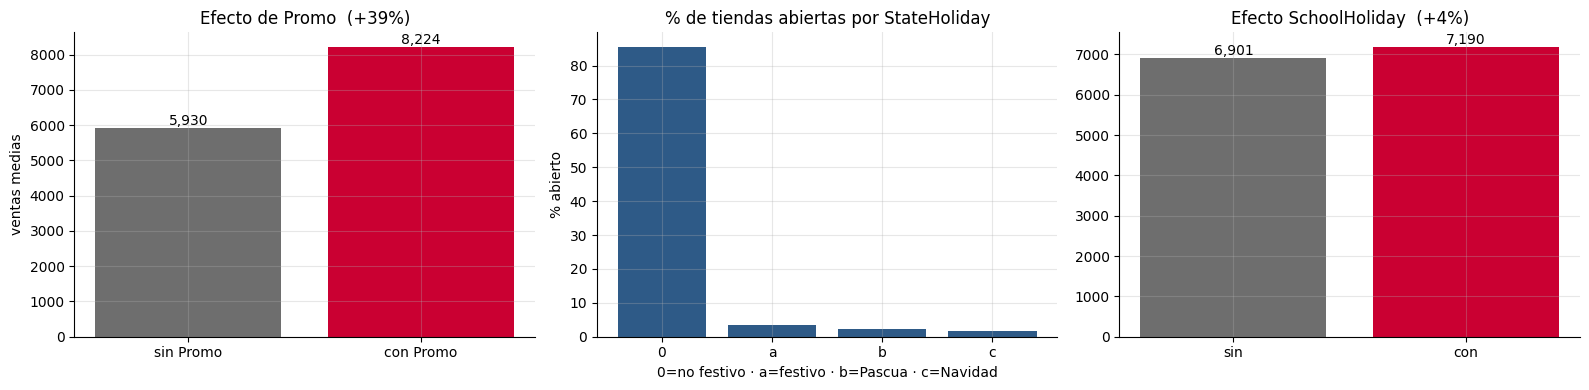

,sales_mean,pct_abierto
StateHoliday,,
0,5947.000,0.855
a,291.000,0.034
b,214.000,0.022
c,169.000,0.017


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Promo
p = abiertas.groupby("Promo")["Sales"].mean()
axes[0].bar(["sin Promo", "con Promo"], p.values, color=[GRIS, ROJO])
for i, v in enumerate(p.values): axes[0].text(i, v, f"{v:,.0f}", ha="center", va="bottom")
axes[0].set_title(f"Efecto de Promo  (+{(p[1]/p[0]-1)*100:.0f}%)"); axes[0].set_ylabel("ventas medias")

# StateHoliday (incluye días cerrados -> usamos train_eda completo para ver el cierre)
sh = train_eda.groupby("StateHoliday").agg(sales_mean=("Sales","mean"), pct_abierto=("Open","mean"))
axes[1].bar(sh.index, sh["pct_abierto"]*100, color=AZUL)
axes[1].set_title("% de tiendas abiertas por StateHoliday")
axes[1].set_xlabel("0=no festivo · a=festivo · b=Pascua · c=Navidad"); axes[1].set_ylabel("% abierto")

# SchoolHoliday
s = abiertas.groupby("SchoolHoliday")["Sales"].mean()
axes[2].bar(["sin", "con"], s.values, color=[GRIS, ROJO])
for i, v in enumerate(s.values): axes[2].text(i, v, f"{v:,.0f}", ha="center", va="bottom")
axes[2].set_title(f"Efecto SchoolHoliday  (+{(s[1]/s[0]-1)*100:.0f}%)")
plt.tight_layout(); plt.show()

display(sh.round({"sales_mean": 0, "pct_abierto": 3}))

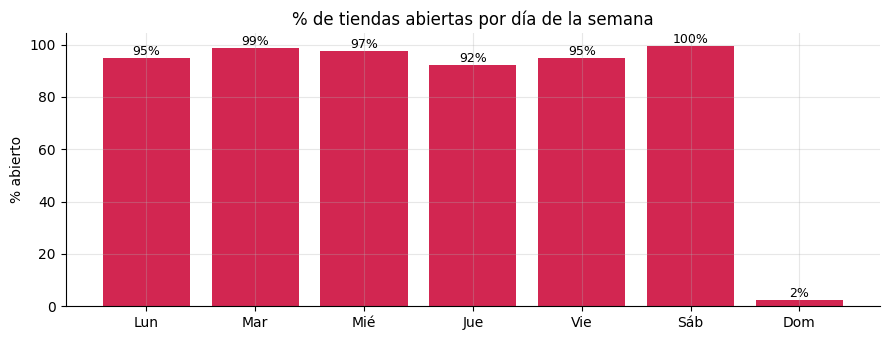

In [15]:
# Patrón de aperturas: % de tiendas abiertas por día de la semana
abre_dow = train_eda.groupby("DayOfWeek")["Open"].mean() * 100
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.bar(range(1, 8), abre_dow.reindex(range(1, 8)).values, color=ROJO, alpha=0.85)
ax.set_xticks(range(1, 8)); ax.set_xticklabels(["Lun","Mar","Mié","Jue","Vie","Sáb","Dom"])
ax.set_title("% de tiendas abiertas por día de la semana"); ax.set_ylabel("% abierto")
for i, v in zip(range(1, 8), abre_dow.reindex(range(1, 8)).values):
    ax.text(i, v, f"{v:.0f}%", ha="center", va="bottom", fontsize=9)
plt.tight_layout(); plt.show()

**Efecto de los eventos**

- **`Promo` es la palanca más potente**: las promociones elevan la venta media ~**+39 %**.
- **`StateHoliday`**: en festivos oficiales (`a`), Pascua (`b`) y Navidad (`c`) la **gran mayoría de tiendas
  cierran** → de nuevo, el evento actúa sobre todo a través de `Open`.
- **`SchoolHoliday`**: efecto positivo leve (~+4 %).
- **Aperturas**: casi todas las tiendas abren de lunes a sábado y **prácticamente todas cierran en domingo**
  (solo ~33 abren). El calendario de aperturas es muy regular.

## <font color='#CA3532'>**9. Atributos de tienda (`store.csv`)**</font>

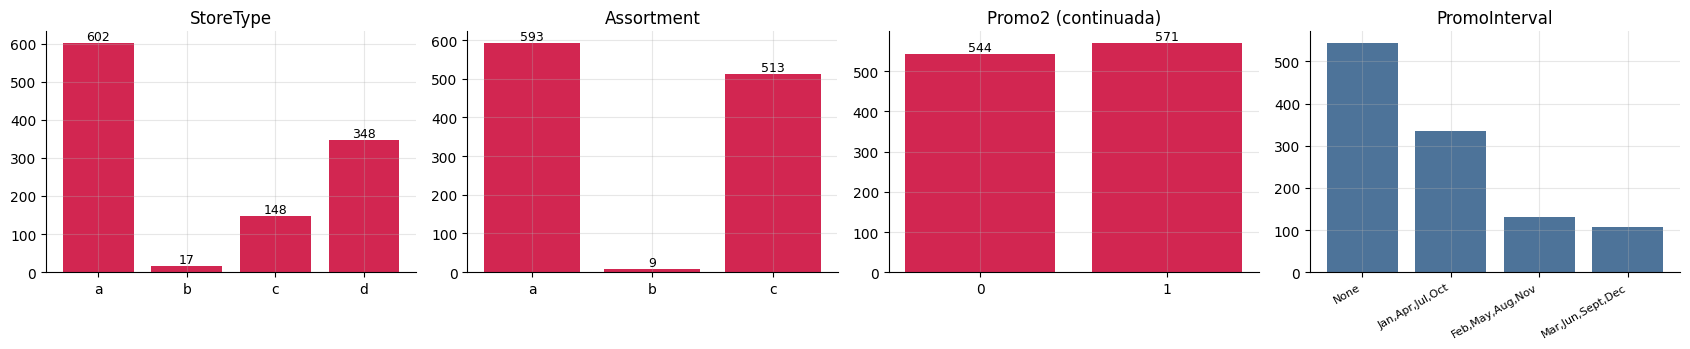

In [16]:
fig, axes = plt.subplots(1, 4, figsize=(17, 3.6))
for ax, col, titulo in [
    (axes[0], "StoreType",     "StoreType"),
    (axes[1], "Assortment",    "Assortment"),
    (axes[2], "Promo2",        "Promo2 (continuada)"),
]:
    vc = store[col].value_counts(dropna=False).sort_index()
    ax.bar(vc.index.astype(str), vc.values, color=ROJO, alpha=0.85)
    ax.set_title(f"{titulo}")
    for i, v in enumerate(vc.values): ax.text(i, v, str(v), ha="center", va="bottom", fontsize=9)

pi = store["PromoInterval"].fillna("None").value_counts()
axes[3].bar(range(len(pi)), pi.values, color=AZUL, alpha=0.85)
axes[3].set_xticks(range(len(pi))); axes[3].set_xticklabels(pi.index, rotation=30, ha="right", fontsize=8)
axes[3].set_title("PromoInterval")
plt.tight_layout(); plt.show()

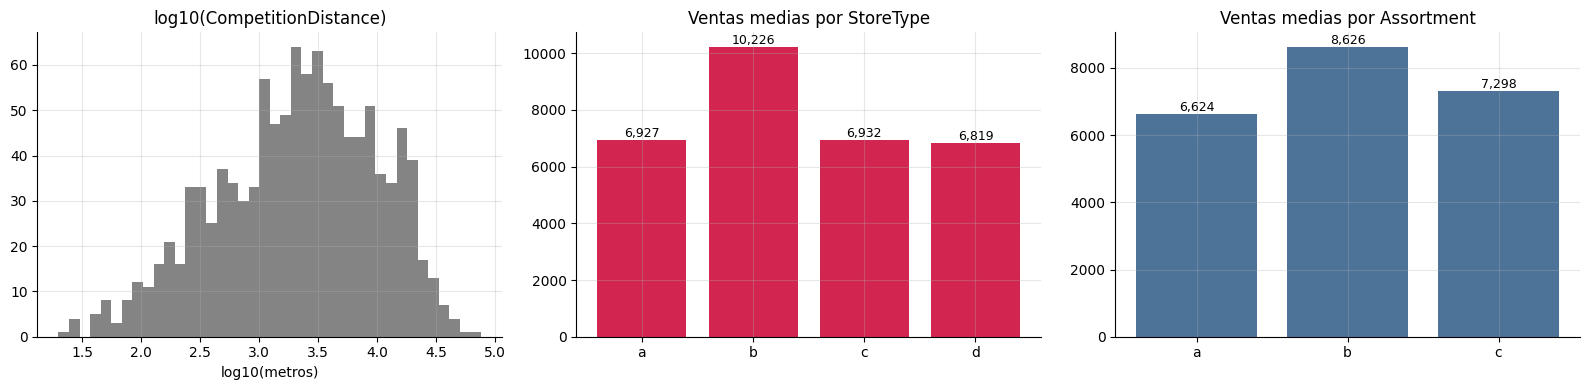

Nº de tiendas por StoreType: {'a': 602, 'd': 348, 'c': 148, 'b': 17}
Nº de tiendas por Assortment: {'a': 593, 'c': 513, 'b': 9}


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Distribución de CompetitionDistance (escala log por el sesgo)
cd = store["CompetitionDistance"].dropna()
axes[0].hist(np.log10(cd), bins=40, color=GRIS, alpha=0.85)
axes[0].set_title("log10(CompetitionDistance)"); axes[0].set_xlabel("log10(metros)")

# Ventas medias por StoreType
vt = abiertas_store.groupby("StoreType")["Sales"].mean()
axes[1].bar(vt.index, vt.values, color=ROJO, alpha=0.85)
for i, v in enumerate(vt.values): axes[1].text(i, v, f"{v:,.0f}", ha="center", va="bottom", fontsize=9)
axes[1].set_title("Ventas medias por StoreType")

# Ventas medias por Assortment
va = abiertas_store.groupby("Assortment")["Sales"].mean()
axes[2].bar(va.index, va.values, color=AZUL, alpha=0.85)
for i, v in enumerate(va.values): axes[2].text(i, v, f"{v:,.0f}", ha="center", va="bottom", fontsize=9)
axes[2].set_title("Ventas medias por Assortment")
plt.tight_layout(); plt.show()

print("Nº de tiendas por StoreType:",  store.StoreType.value_counts().to_dict())
print("Nº de tiendas por Assortment:", store.Assortment.value_counts().to_dict())

**Heterogeneidad entre tiendas**

- **`StoreType`**: predominan `a` (602) y `d` (348); el tipo **`b` es minoritario (17 tiendas) pero vende mucho
  más** (~10 200 €/día frente a ~6 900 del resto) → probablemente hipermercados/centros.
- **`Assortment`**: `a` (básico) y `c` (extendido) dominan; `b` (9 tiendas) es raro pero también vende más.
- **`CompetitionDistance`** está muy sesgada (de 20 m a 75 km) → conviene tratarla en **escala logarítmica**.
- **`Promo2`** divide las tiendas casi por la mitad (571 participan / 544 no).
- Esta variabilidad por tienda es exactamente lo que justifica usar **embeddings** de `Store`, `StoreType`,
  `Assortment` y `PromoInterval` en un modelo de *entradas heterogéneas*.

## <font color='#CA3532'>**10. Correlaciones entre variables numéricas**</font>

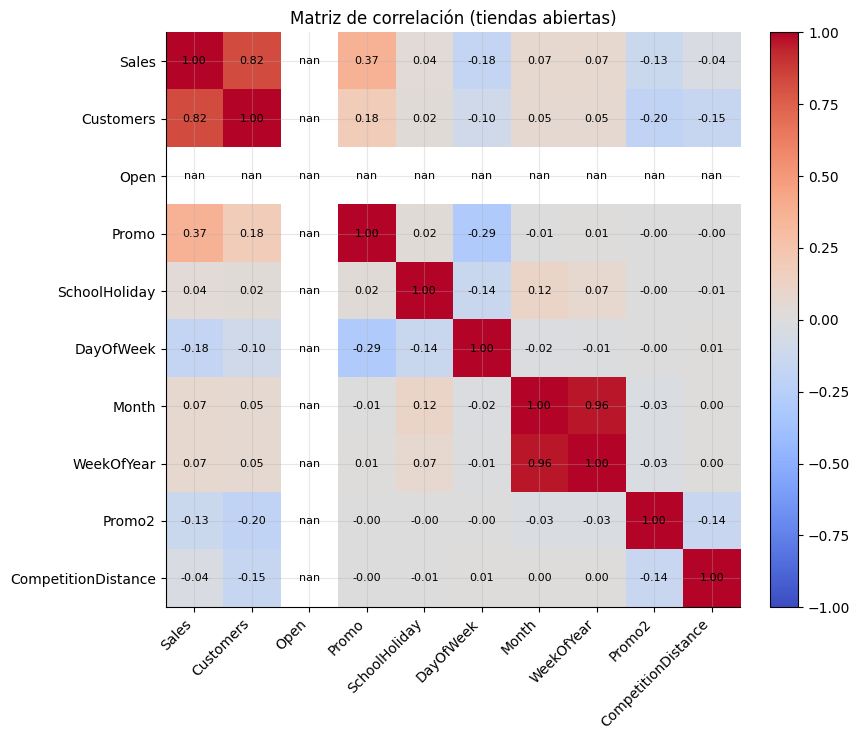

In [18]:
num_cols = ["Sales", "Customers", "Open", "Promo", "SchoolHoliday", "DayOfWeek",
            "Month", "WeekOfYear", "Promo2", "CompetitionDistance"]
corr = abiertas_store[num_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7.5))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center",
                fontsize=8, color="black")
fig.colorbar(im, fraction=0.046, pad=0.04)
ax.set_title("Matriz de correlación (tiendas abiertas)")
plt.tight_layout(); plt.show()

La correlación lineal más alta con `Sales` es la de **`Customers` (0,82)**, seguida a distancia por
**`Promo` (~0,37)**. El resto de relaciones (estacionalidad, tipo de tienda) son **no lineales** y por eso no
se aprecian bien en una matriz de correlación de Pearson: es justamente donde una red neuronal con embeddings
puede aportar valor frente a un modelo lineal.

## <font color='#CA3532'>**11. Comparación `train` vs `test`**</font>

In [19]:
test_eda = test.copy()
test_eda["StateHoliday"] = test_eda["StateHoliday"].astype(str).replace({"0.0": "0"})

print("RANGO TEMPORAL")
print("  train:", train.Date.min().date(), "->", train.Date.max().date())
print("  test :", test.Date.min().date(), "->", test.Date.max().date(),
      f"  ({pd.Timestamp(test.Date.min()).day_name()})")
gap = (test.Date.min() - train.Date.max()).days
print(f"  >>> HUECO de {gap} días entre el final de train y el día de test <<<")
print("\nTIENDAS")
print("  ¿todas las tiendas de test están en train?:", set(test.Store).issubset(set(train.Store)))
print("  nº tiendas test:", test.Store.nunique())
print("\nEXÓGENAS EN TEST (un único día, viernes 2015-07-31)")
print("  Open        :", test_eda.Open.value_counts().to_dict())
print("  Promo       :", test_eda.Promo.value_counts().to_dict())
print("  SchoolHoliday:", test_eda.SchoolHoliday.value_counts().to_dict())
print("  Customers en test?:", "Customers" in test.columns,
      "| nulos:", int(test["Customers"].isna().sum()) if "Customers" in test else "—")

RANGO TEMPORAL
  train: 2013-01-01 -> 2015-07-17
  test : 2015-07-31 -> 2015-07-31   (Friday)
  >>> HUECO de 14 días entre el final de train y el día de test <<<

TIENDAS
  ¿todas las tiendas de test están en train?: True
  nº tiendas test: 1115

EXÓGENAS EN TEST (un único día, viernes 2015-07-31)
  Open        : {1: 1113, 0: 2}
  Promo       : {1: 1115}
  SchoolHoliday: {1: 935, 0: 180}
  Customers en test?: True | nulos: 0


Registros por tienda -> min: 744 | max: 928 | días distintos: 928
Tiendas con histórico INCOMPLETO: 181 (16%)


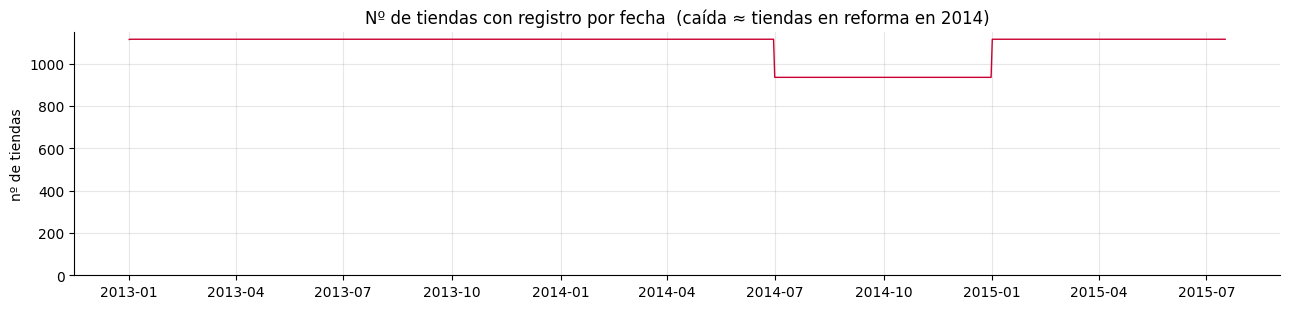

In [20]:
# Series incompletas: nº de tiendas que NO tienen el histórico completo
regs = train.groupby("Store").size()
print("Registros por tienda -> min:", regs.min(), "| max:", regs.max(),
      "| días distintos:", train.Date.nunique())
print("Tiendas con histórico INCOMPLETO:", int((regs < regs.max()).sum()),
      f"({(regs < regs.max()).mean()*100:.0f}%)")

# % de tiendas presentes por fecha (detecta el periodo con ~180 tiendas ausentes)
presentes = train.groupby("Date")["Store"].nunique()
fig, ax = plt.subplots(figsize=(13, 3.2))
ax.plot(presentes.index, presentes.values, color=ROJO, lw=1)
ax.set_title("Nº de tiendas con registro por fecha  (caída ≈ tiendas en reforma en 2014)")
ax.set_ylabel("nº de tiendas"); ax.set_ylim(0, 1150)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.tight_layout(); plt.show()

**Claves de `train` vs `test` (muy relevantes para el modelado)**

- 🔴 **Hueco de 14 días**: `train` termina el 2015-07-17 y `test` es el **2015-07-31**. La predicción **no es
  "el día siguiente"**: hay dos semanas sin datos. El enventanado `horizonte = 1` del notebook base sirve para
  *entrenar/validar*, pero para el test real hay que **proyectar 14 días** (o asumir persistencia de las
  exógenas conocidas: `DayOfWeek`, `Promo`, `Open`...).
- El día de test es un **viernes** con **`Promo = 1` en todas las tiendas** y mayoría en periodo escolar.
- **Todas** las tiendas de test aparecen en train (no hay tiendas nuevas).
- **~181 tiendas (16 %) tienen el histórico incompleto**: hacia mediados de 2014 hay un periodo en el que
  desaparecen ~180 tiendas (cierres por reforma). Hay que **respetar los huecos** al construir las ventanas
  temporales para no mezclar tramos no contiguos.
- En `test` aparece `Customers` (no habitual): refuerza el aviso de *leakage* de la sección 6.

## <font color='#CA3532'>**12. `submission` y \"las 10 tiendas\"**</font>

In [21]:
print("submission.csv -> formato de entrega:", submission.columns.tolist())
display(submission.head())
display(submission["Sales"].describe())
print("\nNota: el enunciado evalúa el R² en 'el test de las 10 tiendas', pero el test.csv local")
print("contiene las", test.Store.nunique(), "tiendas. Conviene confirmar con el profesorado qué")
print("subconjunto exacto se evalúa (p. ej. 10 tiendas concretas) y documentarlo en el notebook.")

submission.csv -> formato de entrega: ['Id', 'Sales']


,Id,Sales
0,879066,5250.649
1,37135,5997.647
2,285919,9207.910
3,744348,12377.561
4,556250,5296.303


count    1115.000
mean     9110.340
std      2999.676
min         0.000
25%      7080.082
50%      8757.465
75%     10612.042
max     25639.830
Name: Sales, dtype: float64


Nota: el enunciado evalúa el R² en 'el test de las 10 tiendas', pero el test.csv local
contiene las 1115 tiendas. Conviene confirmar con el profesorado qué
subconjunto exacto se evalúa (p. ej. 10 tiendas concretas) y documentarlo en el notebook.


El fichero `submission.csv` define el **formato de entrega** (`Id`, `Sales`) y trae unas predicciones de
ejemplo (su media ~9 100 € es superior a la media de `train` porque el día de test es viernes **con promoción
en todas las tiendas**). El criterio de evaluación de la práctica es el **R² sobre el test**; el enunciado
menciona *"las 10 tiendas"*, discrepancia con las 1115 del `test.csv` que conviene **aclarar y justificar**.

## <font color='#CA3532'>**13. Conclusiones del EDA orientadas al modelado**</font>

**Variable objetivo**
- Modelar **solo días abiertos** (`Open==1`) y forzar `Sales=0` cuando `Open==0` (relación casi determinista).
- Usar **`log1p(Sales)`** como objetivo (corrige el fuerte sesgo a la derecha).

**Entradas heterogéneas a utilizar**
- *Endógena temporal*: ventana de `Sales` pasadas por tienda (rama recurrente).
- *Exógenas conocidas*: `Promo`, `DayOfWeek`, `Month`/`WeekOfYear`, `Day`, `SchoolHoliday`, `StateHoliday`.
  `Promo` (+39 %) y el calendario (estacionalidad semanal/anual) son las más informativas.
- *Estáticas de tienda* (→ **embeddings**): `Store`, `StoreType`, `Assortment`, `PromoInterval`;
  más `CompetitionDistance` (en **escala log**) y variables de `Promo2`/competencia.
- ⚠️ **`Customers`**: muy predictiva (corr 0,82) pero potencial *leakage*; documentar y probar un modelo sin ella.

**Preprocesado**
- Imputar nulos de `store` con significado: `CompetitionDistance`→mediana; `Promo2*`/`PromoInterval`→`0`/`"None"`.
- Homogeneizar `StateHoliday` (texto vs entero entre train/test).
- Escalar las variables numéricas; codificar categóricas a índices para los embeddings.
- **Respetar los huecos temporales** (~181 tiendas incompletas) al construir las ventanas.

**Validación y test**
- Partición **temporal** (no aleatoria): validar en las últimas semanas de `train`.
- Tener presente el **hueco de 14 días** hasta el test (la predicción no es a 1 día) y el matiz de
  *"las 10 tiendas"* del enunciado.

**Métricas** sugeridas: **R²** (criterio oficial), además de RMSE y MAE, comparando varias arquitecturas
(baseline persistente → GRU/LSTM solo `Sales` → + exógenas → modelo funcional con embeddings).